Imports

In [2]:
from PIL import Image, ImageDraw, ImageFont
import random, os, json

Font List

In [3]:
import glob

FONT_DIR = "C:/Windows/Fonts"
font_paths = glob.glob(os.path.join(FONT_DIR, "*.ttf"))

def font_is_usable(font_path, test_word="hello0129"):
    try:
        font = ImageFont.truetype(font_path, 24)
        dummy = Image.new('L', (10, 10))
        draw = ImageDraw.Draw(dummy)
        bbox = draw.textbbox((0, 0), test_word, font=font)
        return (bbox[2]-bbox[0]) > 20 and (bbox[3]-bbox[1]) > 5
    except Exception:
        return False

good_fonts = [f for f in font_paths if font_is_usable(f)]
print(len(good_fonts))

bad_fonts = {
    # symbol/dingbat/icon fonts — no real letterforms
    "webdings.ttf", "wingding.ttf", "WINGDNG2.TTF", "WINGDNG3.TTF",
    "symbol.ttf", "BSSYM7.TTF", "MTEXTRA.TTF", "marlett.ttf",
    "REFSPCL.TTF", "seguisym.ttf", "SegoeIcons.ttf", "segmdl2.ttf",
    "l_10646.ttf","OUTLOOK.TTF",

    # non-Latin script fonts — will tofu-box or badly render plain Latin text
    "himalaya.ttf",        # Tibetan
    "mmrtext.ttf", "mmrtextb.ttf",   # Myanmar
    "ntailu.ttf", "ntailub.ttf",       # New Tai Lue
    "taile.ttf", "taileb.ttf",           # Tai Le
    "msyi.ttf",                            # Yi script
    "javatext.ttf",                          # Javanese
    "phagspa.ttf", "phagspab.ttf",             # Phags-pa
    "simsunb.ttf", "SimsunExtG.ttf",             # Chinese
    
}

good_fonts = [f for f in good_fonts if os.path.basename(f) not in bad_fonts]
print(len(good_fonts))

320
293


Word Source

In [4]:
with open("../data/wordlist.txt") as f:
    dictionary_words = [w.strip() for w in f if w.strip().isalpha() and len(w.strip()) >= 2]

def random_sentence(min_words=3, max_words=10):
    n = random.randint(min_words, max_words)
    return [random.choice(dictionary_words) for _ in range(n)]

Mock scrnsht Gen

In [5]:
def get_line_height(font):
    ascent, descent = font.getmetrics()
    return int((ascent + descent) * 1.3)


def get_space_width(font):
    bbox = font.getbbox(" ")
    return max(bbox[2] - bbox[0], 4)


def random_theme(min_contrast=40):
    """
    Procedurally generates a background/text luminance pair.
    min_contrast controls how close bg and text luminance are allowed to be —
    lower values allow harder, low-contrast cases.
    """
    bg = random.randint(0, 255)

    if bg < 128:
        text = random.randint(min(bg + min_contrast, 255), 255)
    else:
        text = random.randint(0, max(bg - min_contrast, 0))

    return (bg, bg, bg), (text, text, text)


def render_header_block(draw, y, width, text_color, boxes):
    font = ImageFont.truetype(random.choice(good_fonts), random.randint(18, 24))
    #print("header font used:", font.path) 
    line_height = get_line_height(font)
    space = get_space_width(font)

    x = 20
    for word in random_sentence(2, 5):
        bbox = draw.textbbox((x, y), word, font=font)
        draw.text((x, y), word, font=font, fill=text_color)
        boxes.append((x, y, bbox[2], bbox[3], word))
        x = bbox[2] + space
    y += line_height

    draw.line([(20, y), (width - 20, y)], fill=(180, 180, 180), width=1)
    y += 20

    return y, boxes


def render_paragraph_block(draw, y, width, height, text_color, boxes):
    font = ImageFont.truetype(random.choice(good_fonts), random.randint(14, 18))
    #print("paragraph font used:", font.path)
    line_height = get_line_height(font)
    space = get_space_width(font)

    n_lines = random.randint(3, 8)
    for _ in range(n_lines):
        x = 20
        line_words = random_sentence(4, 9)
        for word in line_words:
            bbox = draw.textbbox((x, y), word, font=font)
            if bbox[2] > width - 20:
                x = 20
                y += line_height
                bbox = draw.textbbox((x, y), word, font=font)
            draw.text((x, y), word, font=font, fill=text_color)
            boxes.append((x, y, bbox[2], bbox[3], word))
            x = bbox[2] + space
        y += line_height
        if y > height - line_height:
            break

    return y, boxes


def render_chat_bubbles(draw, y, width, height, bg_color, text_color, boxes):
    n_bubbles = random.randint(4, 10)

    for _ in range(n_bubbles):
        font = ImageFont.truetype(random.choice(good_fonts), random.randint(14, 18))
        #print("chat bubble font used:", font.path)
        line_height = get_line_height(font)
        space = get_space_width(font)

        words = random_sentence(2, 6)
        sent = random.random() < 0.5

        widths = []
        for word in words:
            bbox = font.getbbox(word)
            widths.append(bbox[2] - bbox[0])
        total_text_width = sum(widths) + space * (len(words) - 1)
        bubble_width = min(total_text_width + 24, width - 80)

        bubble_x1 = (width - 20 - bubble_width) if sent else 20
        bubble_x2 = bubble_x1 + bubble_width
        bubble_y1 = y
        bubble_y2 = y + line_height + 16

        bubble_fill = tuple(min(255, c + 25) if sum(bg_color) < 400 else max(0, c - 25) for c in bg_color)
        draw.rounded_rectangle([bubble_x1, bubble_y1, bubble_x2, bubble_y2], radius=10, fill=bubble_fill)

        x = bubble_x1 + 12
        text_y = bubble_y1 + 8
        for word in words:
            bbox = draw.textbbox((x, text_y), word, font=font)
            if bbox[2] > bubble_x2 - 12:
                break
            draw.text((x, text_y), word, font=font, fill=text_color)
            boxes.append((x, text_y, bbox[2], bbox[3], word))
            x = bbox[2] + space

        y = bubble_y2 + random.randint(10, 20)
        if y > height - line_height * 2:
            break

    return y, boxes


def render_mock_screenshot(width=800, height=600):
    bg_color, text_color = random_theme()
    img = Image.new('RGB', (width, height), color=bg_color)
    draw = ImageDraw.Draw(img)

    boxes = []
    y = 20

    layout_type = random.choice(['email', 'chat'])

    if layout_type == 'email':
        y, boxes = render_header_block(draw, y, width, text_color, boxes)
        y, boxes = render_paragraph_block(draw, y, width, height, text_color, boxes)
    else:
        y, boxes = render_chat_bubbles(draw, y, width, height, bg_color, text_color, boxes)

    return img, boxes

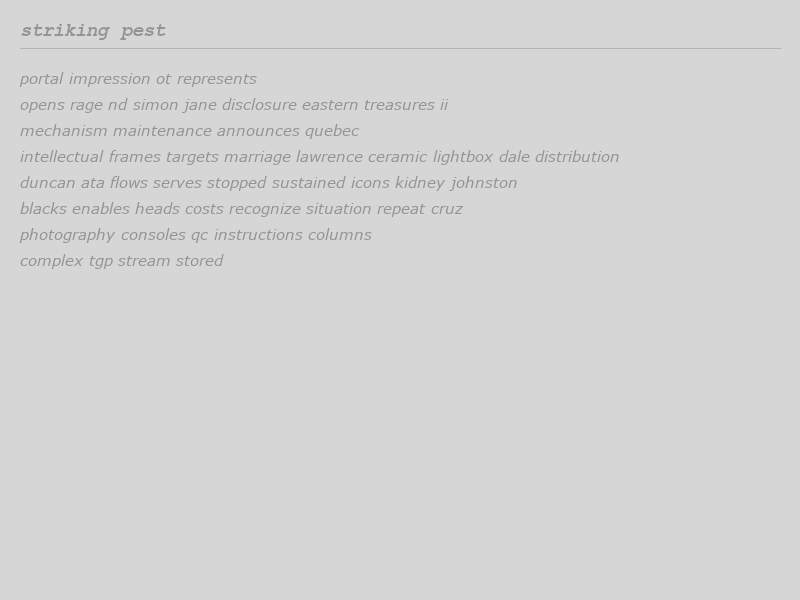

In [9]:
img, boxes = render_mock_screenshot()
img


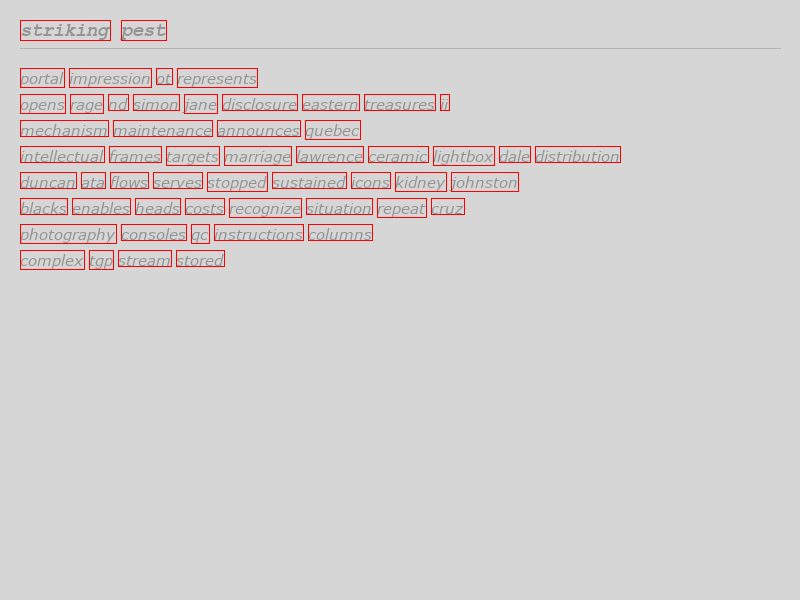

In [10]:

from PIL import ImageDraw as ID

img_check = img.copy()
draw = ID.Draw(img_check)
for x1, y1, x2, y2, word in boxes:
    draw.rectangle([x1, y1, x2, y2], outline=(255,0,0), width=1)
img_check

Mask Generation

In [11]:
import numpy as np

def boxes_to_mask(boxes, width, height):
    """
    Converts a list of (x1, y1, x2, y2, word) boxes into a binary mask,
    same width/height as the source image. 1 = text pixel, 0 = background.
    """
    mask = Image.new('L', (width, height), color=0)
    draw = ImageDraw.Draw(mask)
    for x1, y1, x2, y2, word in boxes:
        draw.rectangle([x1, y1, x2, y2], fill=255)
    return np.array(mask)

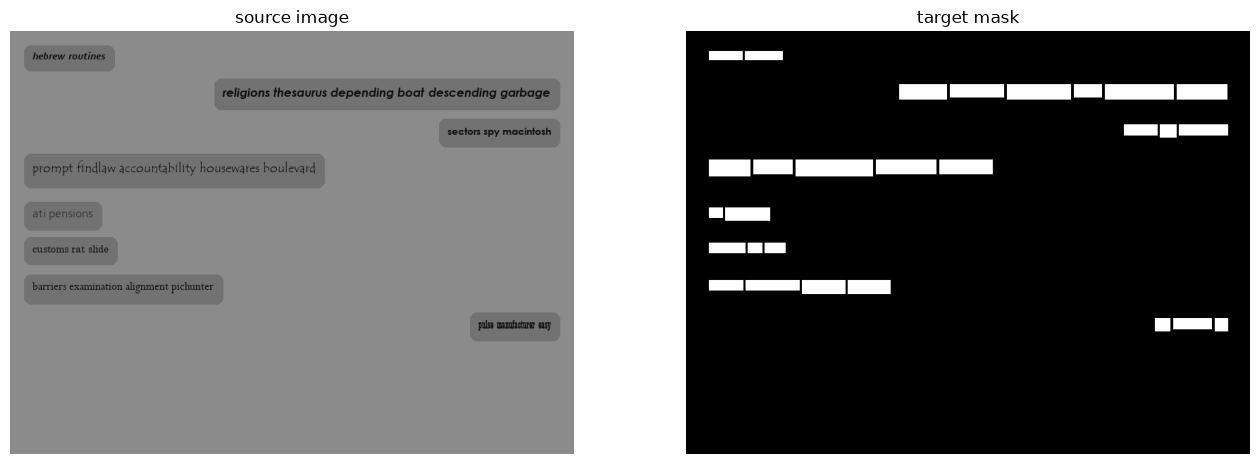

In [12]:
import matplotlib.pyplot as plt
img, boxes = render_mock_screenshot()
mask = boxes_to_mask(boxes, 800, 600)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img)
axes[0].set_title("source image")
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("target mask")
axes[1].axis('off')
plt.show()

Generate at scale

In [583]:
from tqdm import tqdm

os.makedirs("../data/detection/train/images", exist_ok=True)
os.makedirs("../data/detection/train/masks", exist_ok=True)

N = 5000
metadata = []

for i in tqdm(range(N)):
    img, boxes = render_mock_screenshot()
    mask = boxes_to_mask(boxes, 800, 600)

    img_path = f"../data/detection/train/images/{i:05d}.png"
    mask_path = f"../data/detection/train/masks/{i:05d}.png"

    img.save(img_path)
    Image.fromarray(mask).save(mask_path)

    metadata.append({"id": i, "n_boxes": len(boxes)})

with open("../data/detection/train/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"generated {N} image/mask pairs")

  0%|          | 9/5000 [00:00<01:00, 82.31it/s]

chat bubble font used: C:/Windows/Fonts\GILSANUB.TTF
chat bubble font used: C:/Windows/Fonts\AGENCYB.TTF
chat bubble font used: C:/Windows/Fonts\BAUHS93.TTF
chat bubble font used: C:/Windows/Fonts\GILSANUB.TTF
chat bubble font used: C:/Windows/Fonts\malgunbd.ttf
chat bubble font used: C:/Windows/Fonts\MOD20.TTF
chat bubble font used: C:/Windows/Fonts\PERI____.TTF
chat bubble font used: C:/Windows/Fonts\ROCKB.TTF
chat bubble font used: C:/Windows/Fonts\TCCM____.TTF
chat bubble font used: C:/Windows/Fonts\constanz.ttf
chat bubble font used: C:/Windows/Fonts\FRABK.TTF
chat bubble font used: C:/Windows/Fonts\HTOWERT.TTF
chat bubble font used: C:/Windows/Fonts\segoeuil.ttf
chat bubble font used: C:/Windows/Fonts\BOD_R.TTF
chat bubble font used: C:/Windows/Fonts\COPRGTB.TTF
chat bubble font used: C:/Windows/Fonts\tahomabd.ttf
chat bubble font used: C:/Windows/Fonts\arialbd.ttf
chat bubble font used: C:/Windows/Fonts\calibriz.ttf
chat bubble font used: C:/Windows/Fonts\BOD_I.TTF
chat bubble f

  1%|          | 28/5000 [00:00<00:57, 86.18it/s]

header font used: C:/Windows/Fonts\framdit.ttf
paragraph font used: C:/Windows/Fonts\Candarab.ttf
chat bubble font used: C:/Windows/Fonts\CHILLER.TTF
chat bubble font used: C:/Windows/Fonts\corbel.ttf
chat bubble font used: C:/Windows/Fonts\AGENCYR.TTF
chat bubble font used: C:/Windows/Fonts\SitkaVF-Italic.ttf
chat bubble font used: C:/Windows/Fonts\corbell.ttf
chat bubble font used: C:/Windows/Fonts\seguihis.ttf
chat bubble font used: C:/Windows/Fonts\ROCCB___.TTF
chat bubble font used: C:/Windows/Fonts\PLAYBILL.TTF
chat bubble font used: C:/Windows/Fonts\BOD_BI.TTF
chat bubble font used: C:/Windows/Fonts\GARA.TTF
chat bubble font used: C:/Windows/Fonts\verdanai.ttf
chat bubble font used: C:/Windows/Fonts\ARIALN.TTF
chat bubble font used: C:/Windows/Fonts\BRLNSB.TTF
chat bubble font used: C:/Windows/Fonts\segoescb.ttf
chat bubble font used: C:/Windows/Fonts\FELIXTI.TTF
chat bubble font used: C:/Windows/Fonts\BKANT.TTF
chat bubble font used: C:/Windows/Fonts\segoeuib.ttf
chat bubble fo

  1%|          | 46/5000 [00:00<00:58, 85.11it/s]

...

chat bubble font used: C:/Windows/Fonts\calibril.ttf
chat bubble font used: C:/Windows/Fonts\bahnschrift.ttf
chat bubble font used: C:/Windows/Fonts\PERTIBD.TTF
chat bubble font used: C:/Windows/Fonts\segoeuii.ttf
chat bubble font used: C:/Windows/Fonts\CALIST.TTF
chat bubble font used: C:/Windows/Fonts\ebrimabd.ttf
header font used: C:/Windows/Fonts\ROCC____.TTF
paragraph font used: C:/Windows/Fonts\verdanai.ttf
header font used: C:/Windows/Fonts\mvboli.ttf
paragraph font used: C:/Windows/Fonts\ARLRDBD.TTF
chat bubble font used: C:/Windows/Fonts\ROCK.TTF
chat bubble font used: C:/Windows/Fonts\FRAHVIT.TTF
chat bubble font used: C:/Windows/Fonts\GOUDYSTO.TTF
chat bubble font used: C:/Windows/Fonts\BAUHS93.TTF
chat bubble font used: C:/Windows/Fonts\corbel.ttf
chat bubble font used: C:/Windows/Fonts\KUNSTLER.TTF
chat bubble font used: C:/Windows/Fonts\JUICE___.TTF
chat bubble font used: C:/Windows/Fonts\FTLTLT.TTF
chat bubble font used: C:/Windows/Fonts\BROADW.TTF
header font used: C:/W

100%|█████████▉| 4989/5000 [01:03<00:00, 74.35it/s]

chat bubble font used: C:/Windows/Fonts\LCALLIG.TTF
chat bubble font used: C:/Windows/Fonts\LTYPEBO.TTF
chat bubble font used: C:/Windows/Fonts\HARLOWSI.TTF
chat bubble font used: C:/Windows/Fonts\malgunbd.ttf
chat bubble font used: C:/Windows/Fonts\LBRITEI.TTF
chat bubble font used: C:/Windows/Fonts\tahoma.ttf
header font used: C:/Windows/Fonts\bahnschrift.ttf
paragraph font used: C:/Windows/Fonts\trebucbd.ttf
header font used: C:/Windows/Fonts\BRUSHSCI.TTF
paragraph font used: C:/Windows/Fonts\comici.ttf
header font used: C:/Windows/Fonts\malgunbd.ttf
paragraph font used: C:/Windows/Fonts\tahoma.ttf
header font used: C:/Windows/Fonts\LTYPEBO.TTF
paragraph font used: C:/Windows/Fonts\arialbd.ttf
chat bubble font used: C:/Windows/Fonts\FRAMDCN.TTF
chat bubble font used: C:/Windows/Fonts\LFAXD.TTF
chat bubble font used: C:/Windows/Fonts\BOD_CR.TTF
chat bubble font used: C:/Windows/Fonts\GARABD.TTF
chat bubble font used: C:/Windows/Fonts\LSANSDI.TTF
chat bubble font used: C:/Windows/Font

100%|██████████| 5000/5000 [01:03<00:00, 79.10it/s]

header font used: C:/Windows/Fonts\ELEPHNTI.TTF
paragraph font used: C:/Windows/Fonts\GOUDOSI.TTF
chat bubble font used: C:/Windows/Fonts\LTYPE.TTF
chat bubble font used: C:/Windows/Fonts\POORICH.TTF
chat bubble font used: C:/Windows/Fonts\TCM_____.TTF
chat bubble font used: C:/Windows/Fonts\georgiaz.ttf
chat bubble font used: C:/Windows/Fonts\cambriaz.ttf
chat bubble font used: C:/Windows/Fonts\LeelawUI.ttf
chat bubble font used: C:/Windows/Fonts\trebucbi.ttf
chat bubble font used: C:/Windows/Fonts\LSANS.TTF
chat bubble font used: C:/Windows/Fonts\FRAMDCN.TTF
chat bubble font used: C:/Windows/Fonts\ARIALNB.TTF
header font used: C:/Windows/Fonts\ERASDEMI.TTF
paragraph font used: C:/Windows/Fonts\BAUHS93.TTF
generated 5000 image/mask pairs


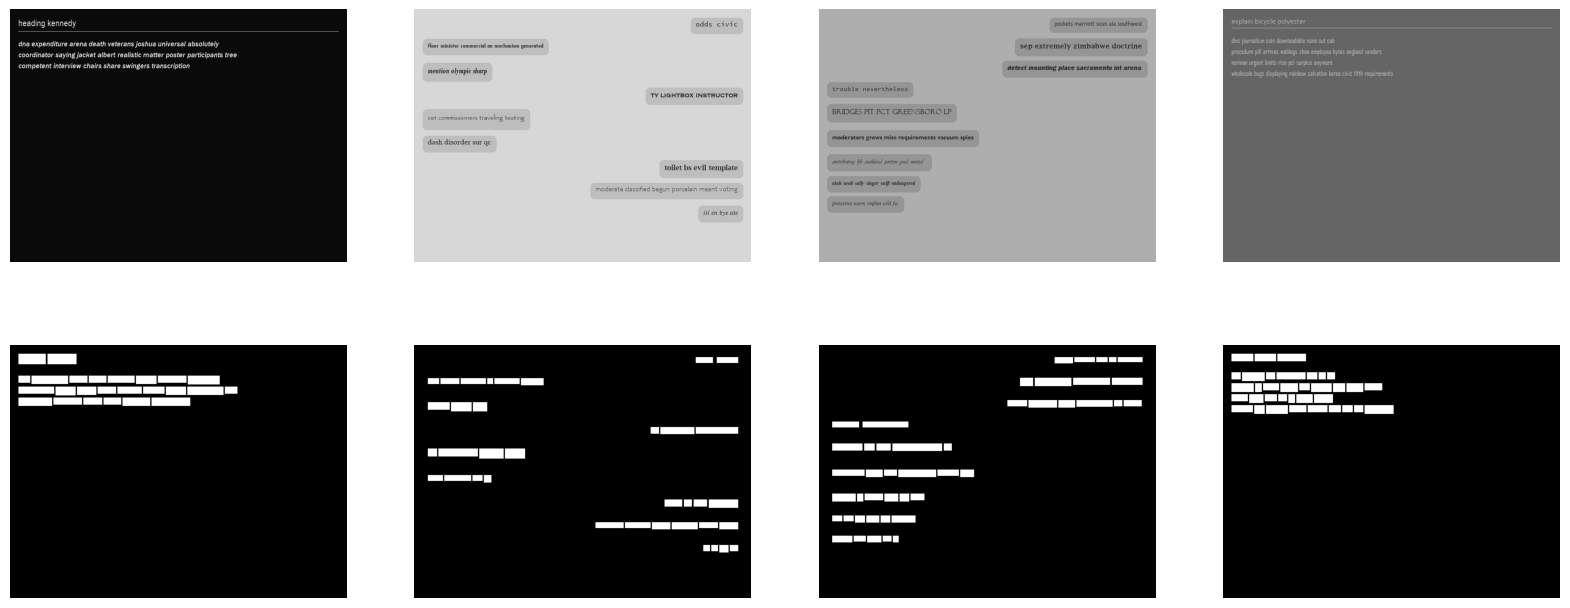

In [584]:
sample_ids = random.sample(range(N), 4)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, sid in enumerate(sample_ids):
    img = Image.open(f"../data/detection/train/images/{sid:05d}.png")
    mask = Image.open(f"../data/detection/train/masks/{sid:05d}.png")
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].axis('off')
plt.show()

In [15]:
from tqdm import tqdm
os.makedirs("../data/detection/train_v2/images", exist_ok=True)
os.makedirs("../data/detection/train_v2/masks", exist_ok=True)

N = 25000
metadata = []

for i in tqdm(range(N)):
    img, boxes = render_mock_screenshot()
    mask = boxes_to_mask(boxes, 800, 600)

    img_path = f"../data/detection/train_v2/images/{i:05d}.png"
    mask_path = f"../data/detection/train_v2/masks/{i:05d}.png"

    img.save(img_path)
    Image.fromarray(mask).save(mask_path)

    metadata.append({"id": i, "n_boxes": len(boxes)})

with open("../data/detection/train_v2/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"generated {N} image/mask pairs")

100%|██████████| 25000/25000 [05:28<00:00, 76.03it/s]


generated 25000 image/mask pairs
